In [1]:
import gzip, random, pandas as pd
from pathlib import Path
import sklearn
import numpy as np
import matplotlib.pyplot as plt

base = Path.home() / "Downloads" / "4650046_files"

In [3]:
import psutil

def max_rows_that_fit(ram_gb=None, n=16, k=8, tfidf_copy=True, overhead=1.5, safe_frac=0.6):
    if ram_gb is None:
        ram_bytes = psutil.virtual_memory().total
    else:
        ram_bytes = ram_gb * (1024**3)
    copies = 2 if tfidf_copy else 1
    bytes_per_row = overhead * 4 * (n*copies + k)
    return int(safe_frac * ram_bytes // bytes_per_row), bytes_per_row

m_max, bpr = max_rows_that_fit(ram_gb=None, n=16, k=8) 
print(f"≈{m_max:,} rows fit safely (bytes/row≈{bpr:.0f})")


≈85,899,345 rows fit safely (bytes/row≈240)


In [5]:
df_timeseries = pd.read_csv(base / "df_timeseries_en.tsv.gz", sep="\t")
df_channels = pd.read_csv(base / "df_channels_en.tsv.gz", sep="\t")

print("timeseries preview:", df_timeseries.shape)
print("channels preview:", df_channels.shape)

timeseries preview: (18872499, 10)
channels preview: (136470, 8)


In [6]:
import pandas as pd

f = pd.read_csv(
    base /"cats_30_filtered.csv.gz",
    sep=",",
    compression="gzip",
)
print(f.shape)


(45823644, 16)


In [7]:
import gzip, pandas as pd

def first_n_tsv(path, n=1000):
    with gzip.open(path, 'rt') as f:
        header = f.readline().strip().split('\t')
        rows = [f.readline().strip().split('\t') for _ in range(n)]
    return pd.DataFrame(rows, columns=header)

comments_sample = first_n_tsv(base / "youtube_comments.tsv.gz", n=1000000)

In [8]:
f = f.rename({"Unnamed: 0":"no_category"},axis=1)

In [9]:
f.head()

,no_category,Autos & Vehicles,Comedy,Education,Entertainment,Film & Animation,Gaming,Howto & Style,Music,News & Politics,Nonprofits & Activism,People & Blogs,Pets & Animals,Science & Technology,Sports,Travel & Events
0,0,0,34,6,83,2,570,5,38,5,0,31,0,3,0,0
1,0,0,1,5,12,0,0,0,16,1,0,5,6,0,0,5
2,0,0,0,0,2,0,2,1,5,0,0,0,0,23,0,0
3,0,0,2,0,16,1,4,1,1,0,0,5,0,0,0,0
4,0,0,4,1,37,3,0,1,1,0,0,8,0,0,1,0


In [10]:
f.shape

(45823644, 16)

coverage per column (lowest 5):
 no_category              0.000565
Nonprofits & Activism    0.142404
Autos & Vehicles         0.200762
Travel & Events          0.247239
Pets & Animals           0.286373
dtype: float64

coverage per column (highest 5):
 Gaming            0.789396
Music             0.819708
Comedy            0.829565
People & Blogs    0.922901
Entertainment     0.980346
dtype: float64

factor f0 top-6:
  Gaming                   50.7438
  Film & Animation         1.0599
  Pets & Animals           0.1408
  no_category              0.0002
  Travel & Events          0.0000
  Sports                   0.0000

factor f1 top-6:
  Entertainment            41.9491
  Film & Animation         2.4511
  Pets & Animals           0.3543
  Travel & Events          0.1170
  no_category              0.0002
  Sports                   0.0000

factor f2 top-6:
  Music                    32.3659
  Film & Animation         0.4774
  Autos & Vehicles         0.1152
  Travel & Events          0.1

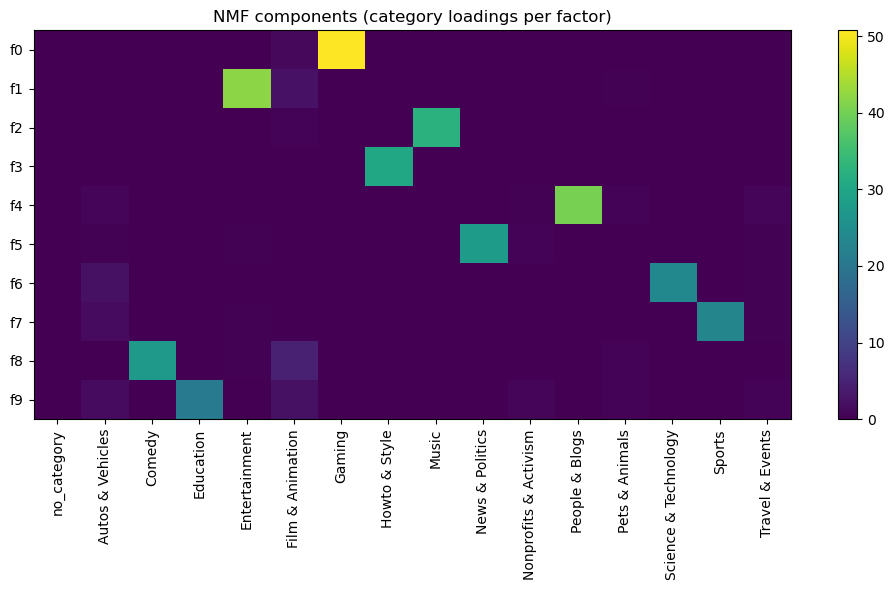

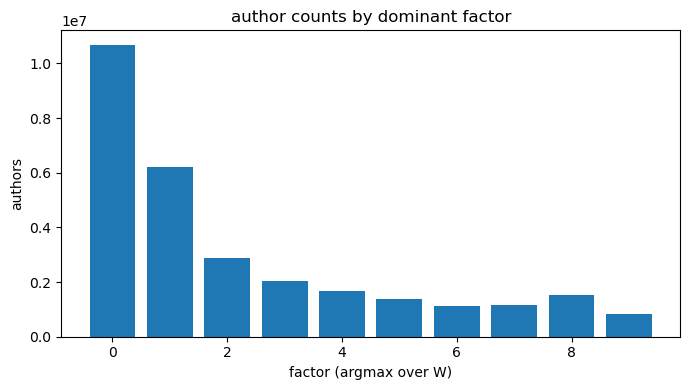

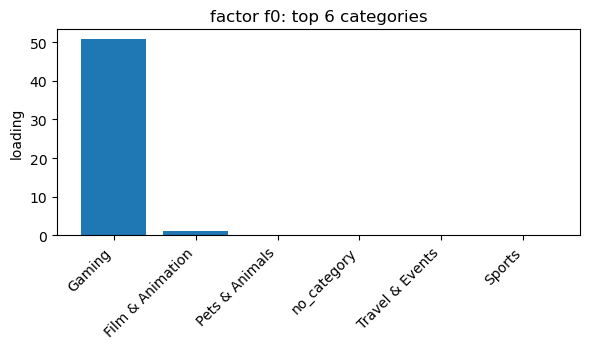

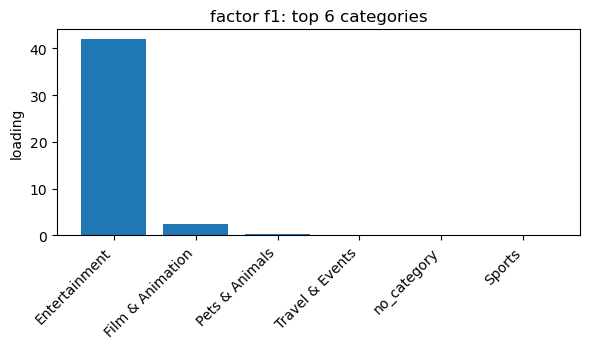

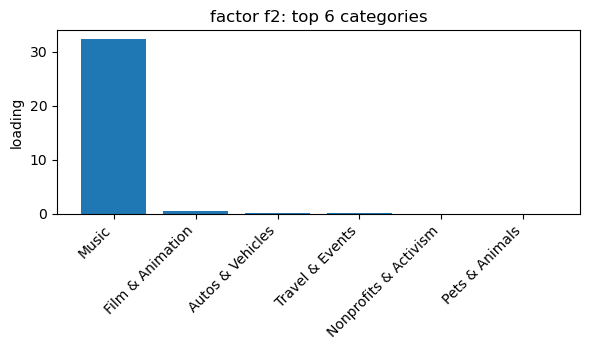

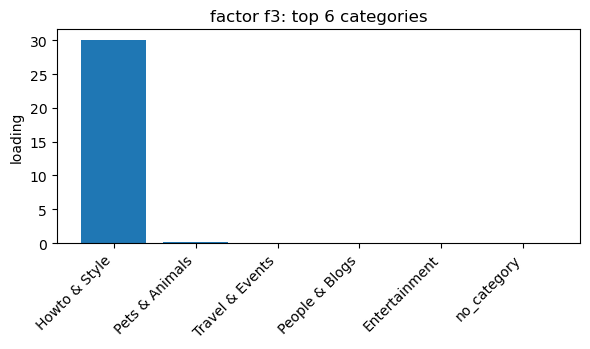

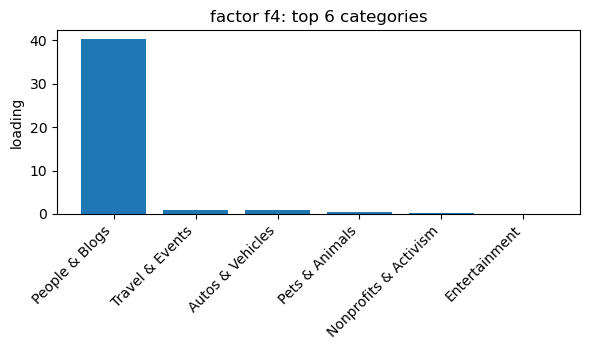

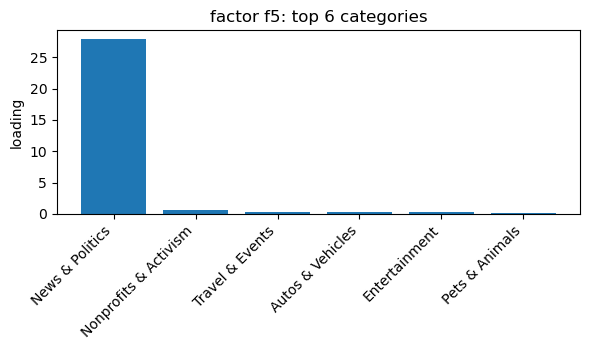

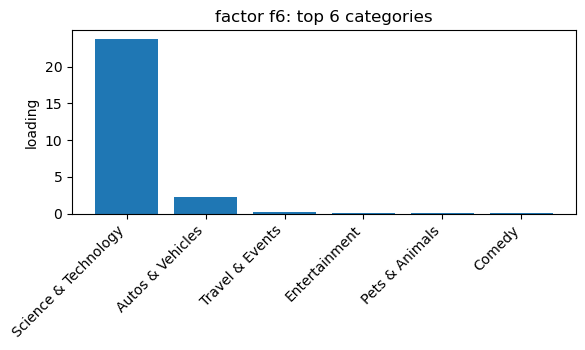

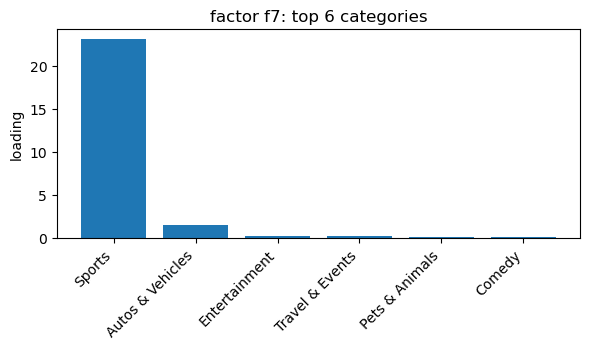

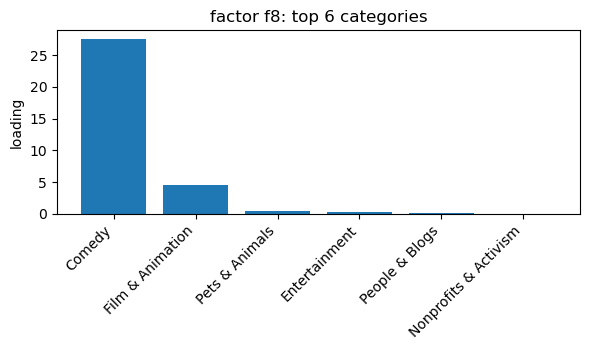

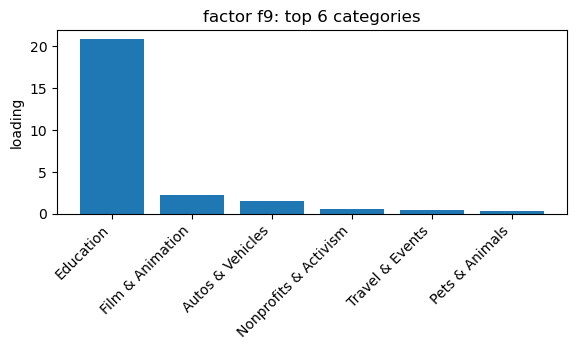

In [61]:
# ===== NMF on author × category counts (complete pipeline) =====
# - starts from DataFrame `f`
# - uses TF-IDF by default so factors reflect preferences (not just popularity)
# - k is configurable; not sure at all

from sklearn.decomposition import NMF

# --------------------------- config ----------------------------
USE_TFIDF     = False     # True = TF-IDF, False = raw counts; try both if curious
K_FACTORS     = 10        # choose ???
MIN_ROW_SUM   = 50        # drop authors with ≤50 total comments -need ram
DROP_UNIVERSAL= False     # drop columns commented by ~everyone (likely "total")
UNIVERSAL_THR = 0.98     # coverage threshold to drop if DROP_UNIVERSAL
DROP_RARE     = False    # optionally drop ultra-rare columns
RARE_THR      = 0        # coverage < 0.5% considered rare
RANDOM_STATE  = 0

#Some cleaning maybe
G = f.select_dtypes(include="number").copy()
G = G[G.sum(axis=1) > MIN_ROW_SUM].copy()
coverage = (G > 0).mean(axis=0).sort_values()
print("coverage per column (lowest 5):\n", coverage.head(5))
print("\ncoverage per column (highest 5):\n", coverage.tail(5))

to_drop = []
if DROP_UNIVERSAL:
    to_drop += coverage[coverage >= UNIVERSAL_THR].index.tolist()
if DROP_RARE and RARE_THR is not None:
    to_drop += coverage[coverage <= RARE_THR].index.tolist()
to_drop = sorted(set(to_drop))
if to_drop:
    print("\ndropping columns due to coverage rule:", to_drop)
    G = G.drop(columns=to_drop)

cats = G.columns.tolist()
X = G.to_numpy(dtype=np.float32, copy=False)
np.nan_to_num(X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

row_sums = X.sum(axis=1, keepdims=True)
TF = X / (row_sums + 1e-12)

if USE_TFIDF:
    n_rows = X.shape[0]
    df_counts = (X > 0).sum(axis=0).astype(np.float32)
    idf = np.log((1.0 + n_rows) / (1.0 + df_counts)) + 1.0
    Xw = TF * idf 
else:
    Xw = TF     

# -----------------------  fit NMF model (NOT SURE ABOUT PARAMETERS:)) ----------------------
nmf = NMF(
    n_components=K_FACTORS,
    init="nndsvd",
    solver="cd",
    beta_loss="frobenius",
    max_iter=1400,
    tol=1e-4,
    random_state=0,
)

W = nmf.fit_transform(Xw).astype(np.float32) 
H = nmf.components_.astype(np.float32)       

# soft memberships as proportions (each row sums to 1)
W_sum = W.sum(axis=1, keepdims=True) + 1e-12
W_prop = (W / W_sum).astype(np.float32)
labels = W_prop.argmax(axis=1)

topn = 6
for i in range(H.shape[0]):
    idx = np.argsort(H[i])[::-1][:topn]
    print(f"\nfactor f{i} top-{topn}:")
    for j in idx:
        print(f"  {cats[j]:<24s} {H[i, j]:.4f}")
rep_n = 10
for i in range(H.shape[0]):
    reps = np.argsort(W_prop[:, i])[-rep_n:][::-1]
    print(f"\nrepresentative rows for f{i}: {reps.tolist()}")

plt.figure(figsize=(10, max(3, 0.6 * K_FACTORS)))
plt.imshow(H, aspect="auto")
plt.xticks(range(len(cats)), cats, rotation=90)
plt.yticks(range(K_FACTORS), [f"f{i}" for i in range(K_FACTORS)])
plt.title("NMF components (category loadings per factor)")
plt.colorbar()
plt.tight_layout()
plt.show()

counts = np.bincount(labels, minlength=K_FACTORS)
plt.figure(figsize=(7, 4))
plt.bar(range(K_FACTORS), counts)
plt.xlabel("factor (argmax over W)")
plt.ylabel("authors")
plt.title("author counts by dominant factor")
plt.tight_layout()
plt.show()

topk = 6
for i in range(H.shape[0]):
    idx = np.argsort(H[i])[::-1][:topk]
    plt.figure(figsize=(6, 3.6))
    plt.bar(range(topk), H[i, idx])
    plt.xticks(range(topk), [cats[j] for j in idx], rotation=45, ha="right")
    plt.ylabel("loading")
    plt.title(f"factor f{i}: top {topk} categories")
    plt.tight_layout()
    plt.show()
out = pd.DataFrame({
    "nmf_label": labels
}, index=G.index)
for i in range(K_FACTORS):
    out[f"f{i}"] = W_prop[:, i]

In [69]:
out.head()

,nmf_label,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,0,0.666830,0.115089,0.069165,0.009828,0.045415,0.010566,0.007169,0.000000,0.065773,0.010164
1,2,0.000000,0.233816,0.405879,0.000841,0.104750,0.031729,0.000652,0.001463,0.024294,0.196576
4,1,0.000000,0.639916,0.022407,0.024062,0.143704,0.000000,0.000000,0.030737,0.105565,0.033610
5,1,0.184324,0.308382,0.040472,0.024336,0.275280,0.015583,0.000000,0.000000,0.147000,0.004624
6,0,0.522793,0.112272,0.000000,0.000000,0.004152,0.013995,0.073819,0.000000,0.254210,0.018759


In [105]:
from collections import Counter, defaultdict

top1_idx   = H.argmax(axis=1)                 
raw_names  = [cats[j] for j in top1_idx]      
counts = Counter(raw_names)
seen = defaultdict(int)
factor_names = []
for name in raw_names:
    seen[name] += 1
    if counts[name] > 1:
        factor_names.append(f"{name}#{seen[name]}") 
        factor_names.append(name)
mem_cols = factor_names
M = pd.DataFrame(W_prop, columns=mem_cols, index=G.index)
label_idx   = labels
label_names = [factor_names[i] for i in label_idx]
out = pd.DataFrame({
    "nmf_label": label_idx,
    "nmf_label_name": label_names,
}, index=G.index).join(M)

H_df = pd.DataFrame(H, columns=cats)
H_df.insert(0, "factor_name", factor_names)

In [85]:
out.head()

,nmf_label,nmf_label_name,Gaming,Entertainment,Music,Howto & Style,People & Blogs,News & Politics,Science & Technology,Sports,Comedy,Education
0,0,Gaming,0.666830,0.115089,0.069165,0.009828,0.045415,0.010566,0.007169,0.000000,0.065773,0.010164
1,2,Music,0.000000,0.233816,0.405879,0.000841,0.104750,0.031729,0.000652,0.001463,0.024294,0.196576
4,1,Entertainment,0.000000,0.639916,0.022407,0.024062,0.143704,0.000000,0.000000,0.030737,0.105565,0.033610
5,1,Entertainment,0.184324,0.308382,0.040472,0.024336,0.275280,0.015583,0.000000,0.000000,0.147000,0.004624
6,0,Gaming,0.522793,0.112272,0.000000,0.000000,0.004152,0.013995,0.073819,0.000000,0.254210,0.018759


In [107]:
label_cols = ["nmf_label", "nmf_label_name"]
mem_cols   = [c for c in out.columns if c not in label_cols]

W = out[mem_cols].to_numpy()
top2_idx = np.argsort(W, axis=1)[:, -2:]            
top1_i   = top2_idx[:, 1]
top2_i   = top2_idx[:, 0]
top1_w   = W[np.arange(W.shape[0]), top1_i]
top2_w   = W[np.arange(W.shape[0]), top2_i]
top1_n   = np.array(mem_cols)[top1_i]
top2_n   = np.array(mem_cols)[top2_i]

TAU_PRIMARY = 0.55
TAU_SECOND  = 0.20

subcat = np.where(
    top1_w >= TAU_PRIMARY,
    top1_n + " core",
    np.where(
        top2_w >= TAU_SECOND,
        (top1_n + "+" + top2_n),
        top1_n + " mixed"  # neither strong primary nor strong second
    ),
)

out["subcat"]       = subcat
out["top1_weight"]  = top1_w
out["top2_weight"]  = top2_w
out["top2_name"]    = top2_n
print(out["subcat"].value_counts().head(20))

subcat
Gaming core                     4794387
Gaming+Entertainment            2176884
Gaming mixed                    1918158
Entertainment mixed             1450120
Entertainment+Gaming            1084886
Music core                      1040778
Entertainment core              1012544
Howto & Style core               833451
Entertainment+People & Blogs     685548
Entertainment+Comedy             627510
Music+Entertainment              625308
News & Politics core             539695
Entertainment+Music              538885
Gaming+Comedy                    513711
Comedy+Entertainment             506104
Music mixed                      502272
People & Blogs+Entertainment     485838
Gaming+Music                     389722
Science & Technology core        379548
Sports core                      363000
Name: count, dtype: int64


In [109]:
out.head()

,nmf_label,nmf_label_name,Gaming,Entertainment,Music,Howto & Style,People & Blogs,News & Politics,Science & Technology,Sports,Comedy,Education,subcat,top1_weight,top2_weight,top2_name
0,0,Gaming,0.666830,0.115089,0.069165,0.009828,0.045415,0.010566,0.007169,0.000000,0.065773,0.010164,Gaming core,0.666830,0.115089,Entertainment
1,2,Music,0.000000,0.233816,0.405879,0.000841,0.104750,0.031729,0.000652,0.001463,0.024294,0.196576,Music+Entertainment,0.405879,0.233816,Entertainment
4,1,Entertainment,0.000000,0.639916,0.022407,0.024062,0.143704,0.000000,0.000000,0.030737,0.105565,0.033610,Entertainment core,0.639916,0.143704,People & Blogs
5,1,Entertainment,0.184324,0.308382,0.040472,0.024336,0.275280,0.015583,0.000000,0.000000,0.147000,0.004624,Entertainment+People & Blogs,0.308382,0.275280,People & Blogs
6,0,Gaming,0.522793,0.112272,0.000000,0.000000,0.004152,0.013995,0.073819,0.000000,0.254210,0.018759,Gaming+Comedy,0.522793,0.254210,Comedy


   orig_index                                         top_counts  \
0    23303391  Sports:88, no_category:0, Autos & Vehicles:0, ...   
1     4259641  Sports:66, no_category:0, Autos & Vehicles:0, ...   
2     8685774  Sports:104, Entertainment:1, Film & Animation:...   
3    30183851  Sports:237, no_category:0, Autos & Vehicles:0,...   
4    19310474  Sports:97, no_category:0, Autos & Vehicles:0, ...   
5    17889689  Sports:65, no_category:0, Autos & Vehicles:0, ...   
6     3371416  Sports:57, no_category:0, Autos & Vehicles:0, ...   
7    26152959  Sports:176, Entertainment:1, no_category:0, Au...   
8     1197128  Sports:55, no_category:0, Autos & Vehicles:0, ...   
9    14143420  Sports:92, Film & Animation:1, no_category:0, ...   

                                           top_props  
0  Sports:1.00, no_category:0.00, Autos & Vehicle...  
1  Sports:1.00, no_category:0.00, Autos & Vehicle...  
2  Sports:0.98, Entertainment:0.01, Film & Animat...  
3  Sports:1.00, no_category:0.0

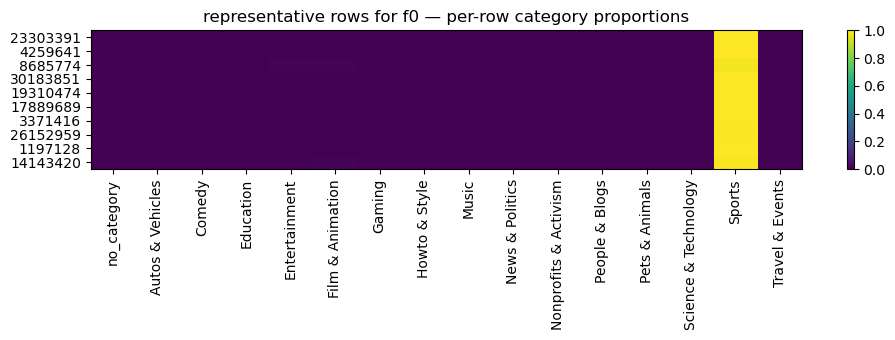

In [63]:
# ourr representative positions for factor 0: TO SEE SOME ROWS AND UNDERSTAND THEM.
pos = np.array([14979349, 2738754, 5583579, 19402322, 12412711, 11500383, 2167918, 16810354, 769797, 9091718])

orig_idx = G.index.to_numpy()[pos]     
rows_f = f.loc[orig_idx]          
rows_G = G.iloc[pos]               

cats = rows_G.columns.tolist()
props = rows_G.div(rows_G.sum(axis=1), axis=0)

def topk_counts(s, k=5):
    s = s.astype(float)
    top = s.sort_values(ascending=False).head(k)
    return ", ".join(f"{c}:{int(v)}" for c,v in top.items())

def topk_props(s, k=5):
    top = s.sort_values(ascending=False).head(k)
    return ", ".join(f"{c}:{v:.2f}" for c,v in top.items())

summary = pd.DataFrame({
    "orig_index": orig_idx,
    "top_counts": [topk_counts(rows_G.iloc[i]) for i in range(len(pos))],
    "top_props":  [topk_props(props.iloc[i])   for i in range(len(pos))]
})
print(summary)

weights = pd.DataFrame(W_prop[pos], columns=[f"f{i}" for i in range(W_prop.shape[1])], index=orig_idx)
weights = weights.sort_values("f0", ascending=False)
print(weights.head(10))
plt.figure(figsize=(10, 3.5))
plt.imshow(props.to_numpy(), aspect="auto")
plt.xticks(range(len(cats)), cats, rotation=90)
plt.yticks(range(len(pos)), [str(i) for i in orig_idx])
plt.title("representative rows for f0 — per-row category proportions")
plt.colorbar()
plt.tight_layout()
plt.show()

if 'author_id' in f.columns:
    ids = f.loc[orig_idx, 'author_id']
    view = pd.concat([ids.rename('author_id'), weights], axis=1)
    print(view.head(10))


In [123]:
out.head()

,nmf_label,nmf_label_name,Gaming,Entertainment,Music,Howto & Style,People & Blogs,News & Politics,Science & Technology,Sports,Comedy,Education,subcat,top1_weight,top2_weight,top2_name,primary,secondary
0,0,Gaming,0.666830,0.115089,0.069165,0.009828,0.045415,0.010566,0.007169,0.000000,0.065773,0.010164,Gaming core,0.666830,0.115089,Entertainment,Gaming,None
1,2,Music,0.000000,0.233816,0.405879,0.000841,0.104750,0.031729,0.000652,0.001463,0.024294,0.196576,Music+Entertainment,0.405879,0.233816,Entertainment,Music,Entertainment
4,1,Entertainment,0.000000,0.639916,0.022407,0.024062,0.143704,0.000000,0.000000,0.030737,0.105565,0.033610,Entertainment core,0.639916,0.143704,People & Blogs,Entertainment,None
5,1,Entertainment,0.184324,0.308382,0.040472,0.024336,0.275280,0.015583,0.000000,0.000000,0.147000,0.004624,Entertainment+People & Blogs,0.308382,0.275280,People & Blogs,Entertainment,People & Blogs
6,0,Gaming,0.522793,0.112272,0.000000,0.000000,0.004152,0.013995,0.073819,0.000000,0.254210,0.018759,Gaming+Comedy,0.522793,0.254210,Comedy,Gaming,Comedy


In [139]:
out.shape

(29454768, 18)

In [ ]:
from matplotlib.ticker import FuncFormatter

s = out["subcat"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(s.index, s.values)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.set_xlabel("Authors")
ax.set_title("Subcategory counts")
ax.bar_label(bars, labels=[f"{v:,}" for v in s.values], padding=3)
plt.show()


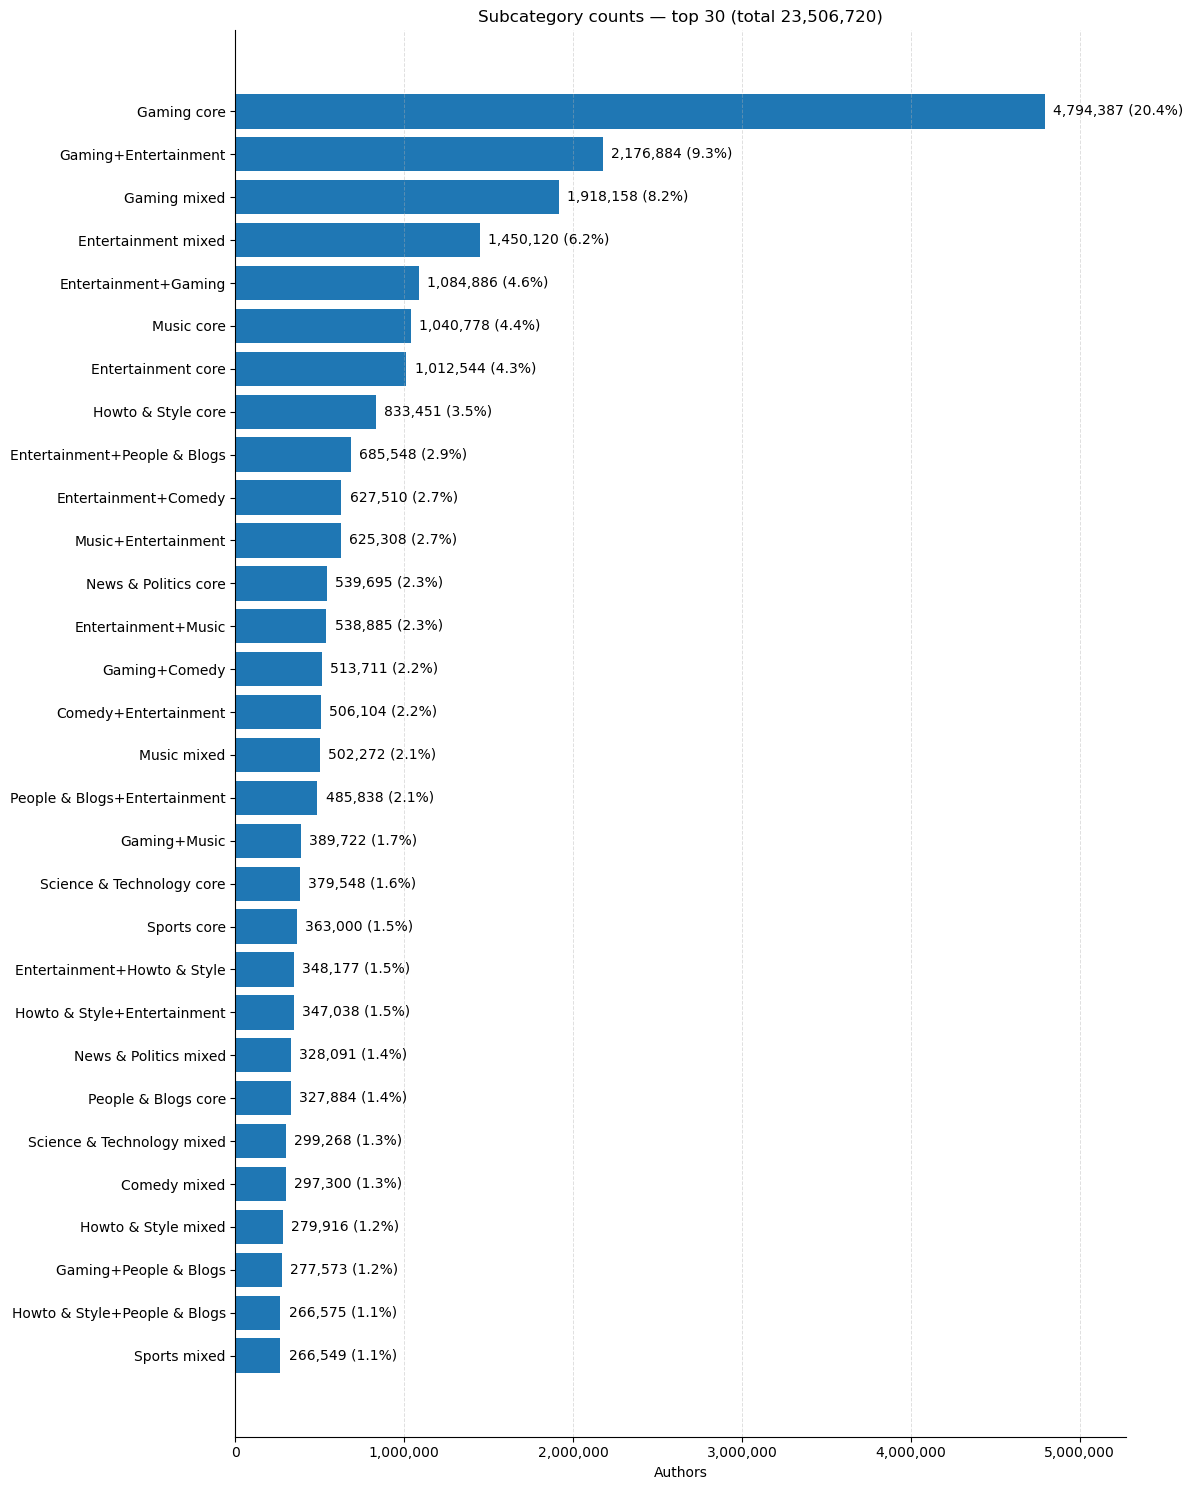

In [156]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import textwrap

s = (out["subcat"].dropna().value_counts().sort_values(ascending=False))
top_n = 30
s = s.head(top_n)

labels = ["\n".join(textwrap.wrap(str(lbl), width=28)) for lbl in s.index]
total = int(s.sum())
fig_h = max(4, 0.45 * len(s) + 1.5)

fig, ax = plt.subplots(figsize=(12, fig_h))
bars = ax.barh(labels, s.values)
ax.invert_yaxis()
ax.set_xlim(0, s.values.max() * 1.1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.set_xlabel("Authors")
ax.set_title(f"Subcategory counts — top {len(s)} (total {total:,})")

for bar, v in zip(bars, s.values):
    ax.text(v + s.values.max()*0.01, bar.get_y() + bar.get_height()/2,
            f"{int(v):,} ({v/total:.1%})", va="center", ha="left")

ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
for spine in ("top","right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


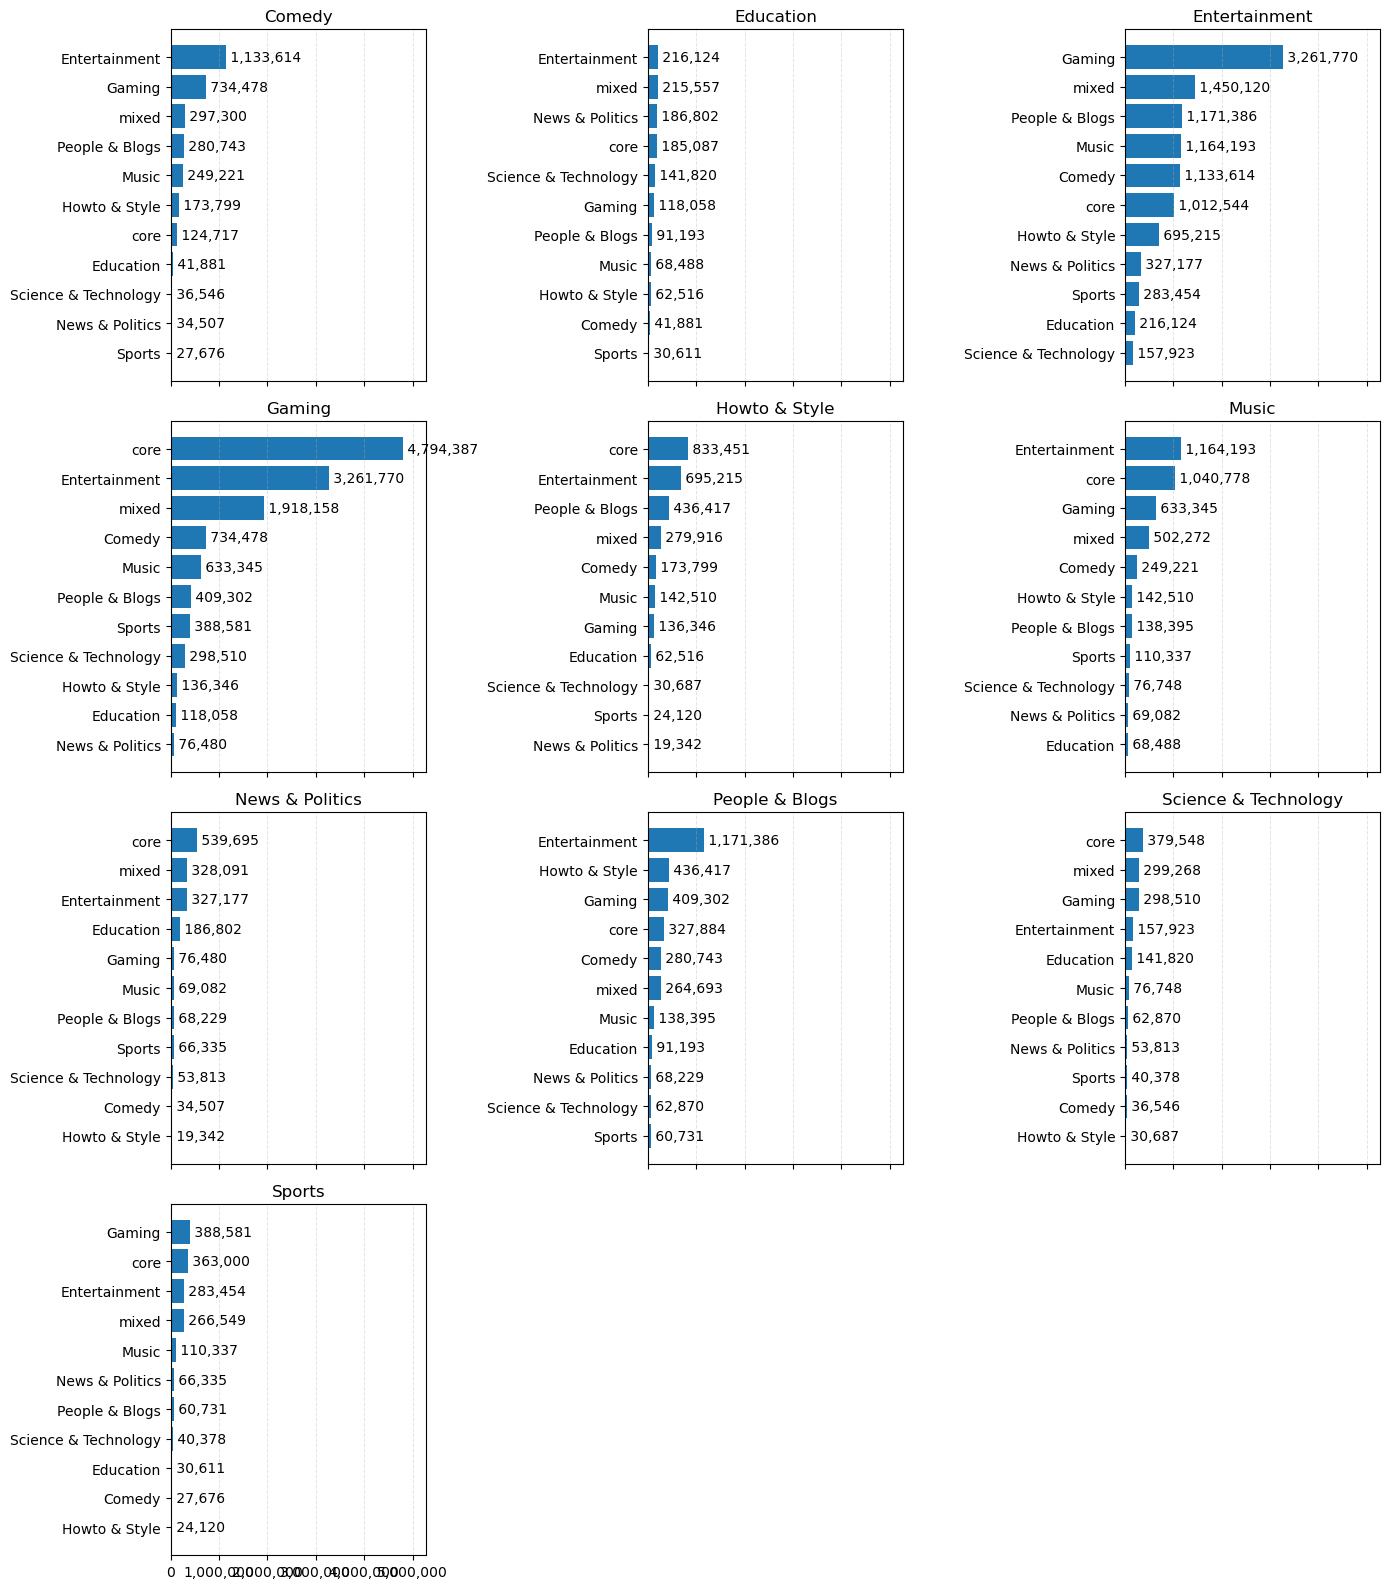

In [160]:
s = out["subcat"].dropna().value_counts()

def parse_cats(label):
    base = re.sub(r"\s+(core|mixed)\s*$", "", str(label)).strip()
    return [p.strip() for p in base.split("+")]
mains = sorted({c for lbl in s.index for c in parse_cats(lbl)})

def counts_for(main, series):
    d = {}
    c = series.get(f"{main} core", 0)
    m = series.get(f"{main} mixed", 0)
    if c: d["core"] = int(c)
    if m: d["mixed"] = int(m)
    pairs = series[series.index.str.contains(r"\+", regex=True)]
    for lbl, cnt in pairs.items():
        cats = parse_cats(lbl)
        if main in cats and len(cats) == 2:
            other = cats[0] if cats[1] == main else cats[1]
            d[other] = d.get(other, 0) + int(cnt)
    return pd.Series(d, dtype="float64")

top_k = 12
series_list = []
max_x = 0
for main in mains:
    ser = counts_for(main, s)
    if ser.empty:
        continue
    ser = ser.sort_values(ascending=False).head(top_k).sort_values(ascending=True)
    series_list.append((main, ser))
    if ser.max() > max_x:
        max_x = float(ser.max())

cols = 3
rows = (len(series_list) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax in axes:
    ax.axis("off")

for ax, (main, ser) in zip(axes, series_list):
    ax.axis("on")
    bars = ax.barh(ser.index, ser.values)
    ax.set_title(main)
    ax.set_xlim(0, max_x * 1.1)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
    for b, v in zip(bars, ser.values):
        ax.text(v, b.get_y() + b.get_height() / 2, f" {int(v):,}", va="center")
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.35)

plt.tight_layout()
plt.show()

In [7]:
file = base / "yt_metadata_helper.feather"
df = pd.read_feather(file)

print("rows:", len(df))
print("columns:", df.columns[:10])  # show first 10 column names

rows: 72924794
columns: Index(['categories', 'channel_id', 'dislike_count', 'display_id', 'duration',
       'like_count', 'upload_date', 'view_count'],
      dtype='object')


In [13]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict
from pathlib import Path

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

valid_videos = set(df["display_id"].astype(str).unique())
comments = comments.copy()
comments["author"] = comments["author"].astype(str)
comments["video_id"] = comments["video_id"].astype(str)

if len(valid_videos) > 0:
    comments = comments[comments["video_id"].isin(valid_videos)].copy()
authors_per_video = (
    comments.groupby("video_id")["author"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)

# Count co-occurrences across videos (edge weights)
edge_weights = defaultdict(int)
node_set = set()
for vid, authors in authors_per_video.items():
    node_set.update(authors)
    if len(authors) < 2:
        continue
    for a, b in combinations(authors, 2):
        if a == b: 
            continue
        key = (a, b) if a < b else (b, a)
        edge_weights[key] += 1

nodes = sorted(node_set)
node_idx = {n:i for i,n in enumerate(nodes)}
used_algo = None
labels = None

try:
    import igraph as ig
    import leidenalg as la
    g = ig.Graph()
    g.add_vertices(len(nodes))
    g.vs["name"] = nodes

    if edge_weights:
        edges = [(node_idx[a], node_idx[b]) for (a,b), w in edge_weights.items() if w > 0]
        weights = [w for (a,b), w in edge_weights.items() if w > 0]
        g.add_edges(edges)
        g.es["weight"] = weights
    else:
        edges = []
        weights = []
    part = la.find_partition(g, la.ModularityVertexPartition, weights=g.es["weight"] if "weight" in g.es.attributes() else None)
    labels = np.array(part.membership)
    used_algo = f"Leiden (modularity), communities={len(set(labels))}"
except Exception as e_leiden:
    try:
        import networkx as nx
        import community as community_louvain

        G = nx.Graph()
        G.add_nodes_from(nodes)
        for (a,b), w in edge_weights.items():
            G.add_edge(a, b, weight=w)

        if G.number_of_edges() == 0:
            labels = np.zeros(len(nodes), dtype=int)
            used_algo = "Trivial (no edges)"
        else:
            partition = community_louvain.best_partition(G, weight="weight", random_state=42)
            # map node -> label array
            labels = np.array([partition[n] for n in nodes])
            used_algo = f"Louvain, communities={len(set(labels))}"
    except Exception as e_louvain:
        # Fallback to NetworkX greedy modularity
        import networkx as nx
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for (a,b), w in edge_weights.items():
            G.add_edge(a, b, weight=w)

        if G.number_of_edges() == 0:
            labels = np.zeros(len(nodes), dtype=int)
            used_algo = "Trivial (no edges)"
        else:
            comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
            # assign cluster ids
            node2lab = {}
            for i, com in enumerate(comms):
                for n in com:
                    node2lab[str(n)] = i
            labels = np.array([node2lab.get(n, -1) for n in nodes])
            used_algo = f"NetworkX Greedy Modularity, communities={len(comms)}"

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [15]:
out = pd.DataFrame({
    "author": nodes,
    "cluster": labels
})

sizes = out["cluster"].value_counts().rename_axis("cluster").reset_index(name="cluster_size")
out = out.merge(sizes, on="cluster", how="left")
deg = defaultdict(int)
wdeg = defaultdict(float)
for (a,b), w in edge_weights.items():
    deg[a] += 1
    deg[b] += 1
    wdeg[a] += w
    wdeg[b] += w

out["degree"] = out["author"].map(lambda x: deg.get(x, 0))
out["weighted_degree"] = out["author"].map(lambda x: wdeg.get(x, 0.0))

# Optionally, attach simple activity stats (how many distinct videos, total comments by author)
author_vids = comments.groupby("author")["video_id"].nunique().rename("distinct_videos")
author_rows = comments.groupby("author")["video_id"].size().rename("comment_rows")
out = out.merge(author_vids, on="author", how="left").merge(author_rows, on="author", how="left")

# Save
out_path = base /"author_leiden_clusters.csv"
out.sort_values(["cluster","weighted_degree","degree","author"], ascending=[True, False, False, True]).to_csv(out_path, index=False)

# Show preview
preview = out.sort_values(["cluster","weighted_degree","degree","author"], ascending=[True, False, False, True]).head(20)
if display_dataframe_to_user:
    display_dataframe_to_user(f"Author clusters ({used_algo}) — preview", preview)

out_path, used_algo

(PosixPath('/Users/es/Downloads/4650046_files/author_leiden_clusters.csv'),
 'Leiden (modularity), communities=3823')

In [21]:
out.head()

,author,cluster,cluster_size,degree,weighted_degree,distinct_videos,comment_rows
0,1,8,100,1,1.0,5,5
1,10,126,1,0,0.0,3,3
2,100,127,1,0,0.0,1,2
3,1001,128,1,0,0.0,1,1
4,1002,129,1,0,0.0,1,1
